In [142]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split,cross_val_score)
from sklearn.preprocessing import (LabelEncoder,StandardScaler)
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,classification_report,confusion_matrix,roc_curve,auc)
from imblearn.over_sampling import SMOTE

# DATA UNDERSTANDING

In [143]:
# Path ke folder dataset
df = pd.read_csv('/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [144]:
#Lihat 5 Data Pertama
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [145]:
#Melihat Informasi Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [146]:
# Melihat Jumlah Baris dan Kolom
df.shape

(7043, 21)

In [147]:
#Cek Missing Value
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [148]:
#Cek Data Duplikat
df.duplicated().sum()

np.int64(0)

# EDA

In [149]:
# Persentase Churn
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

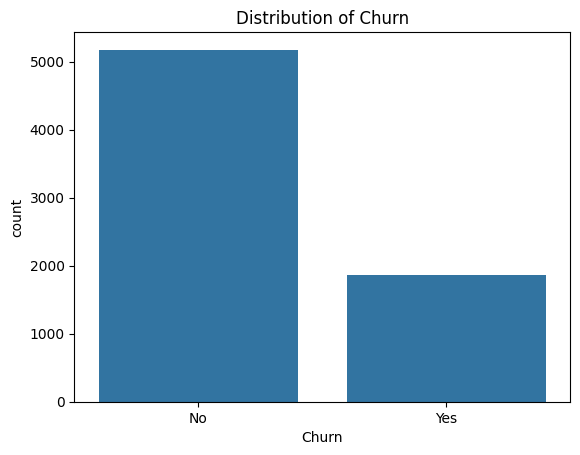

In [150]:
# Cek Distribusi Customer Churn
sns.countplot(x='Churn', data=df)
plt.title('Distribution of Churn')
plt.show()

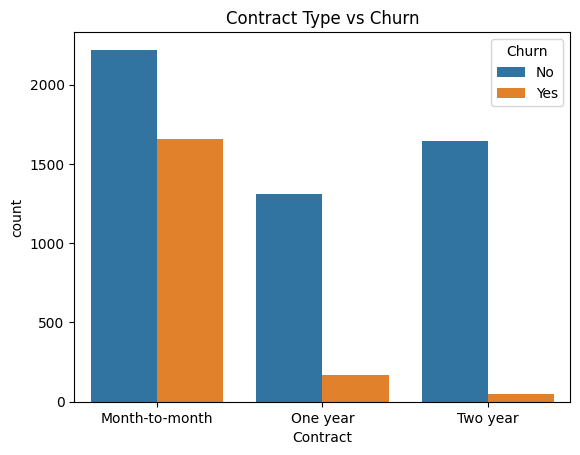

In [151]:
# Distribusi Contract vs Churn
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Contract Type vs Churn')
plt.show()

**Month-to-month** customers are very susceptible to **churn**

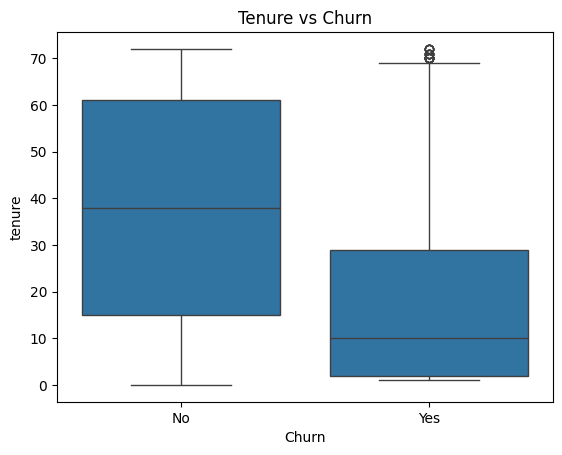

In [152]:
# Ditribusi Tenure VS Churn
# Boxplot digunakan untuk membandingkan fitur numerik dan kategorikal target.
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure vs Churn')
plt.show()

**new customers** churn more often

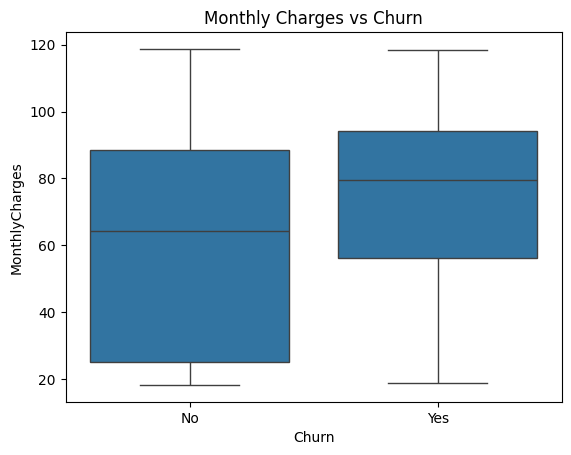

In [153]:
# Distribusi Churn VS MonthlyCharges
# Boxplot digunakan untuk membandingkan fitur numerik dan kategorikal target.
sns.boxplot(x='Churn', y='MonthlyCharges', data=df) 
plt.title('Monthly Charges vs Churn')
plt.show()

high monthly costs → higher churn

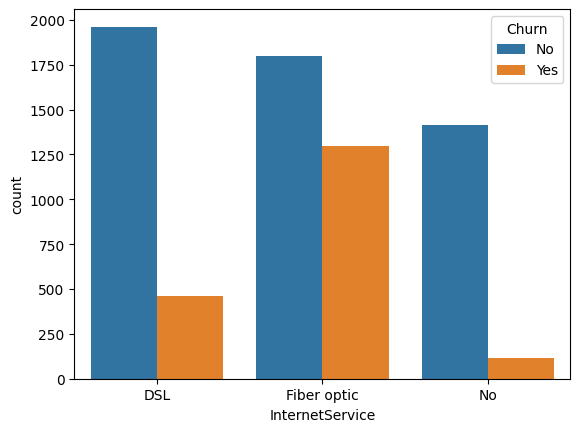

In [154]:
# Internet Service VS Churn
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.show()

customers with **Fiber optic** internet service have higher churn

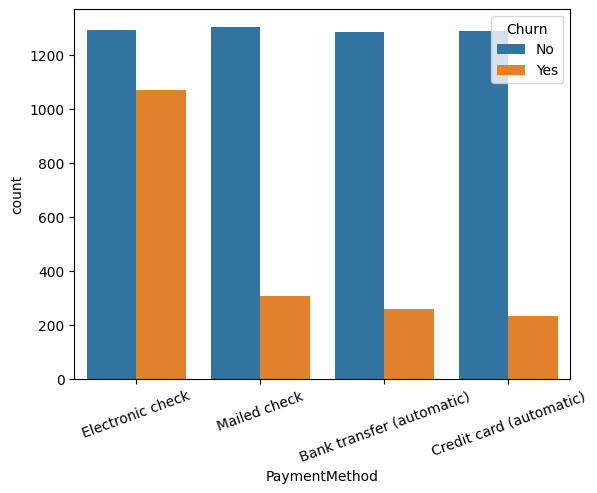

In [155]:
# Distribusi Payment Method VS Churn
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=20)
plt.show()

customers with **electronic checks** have high churn

In [156]:
# Heatmap Correlation
df_encoded = df.copy() #encoding karna banyak fitur kategorikal

for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = pd.factorize(df_encoded[col])[0]

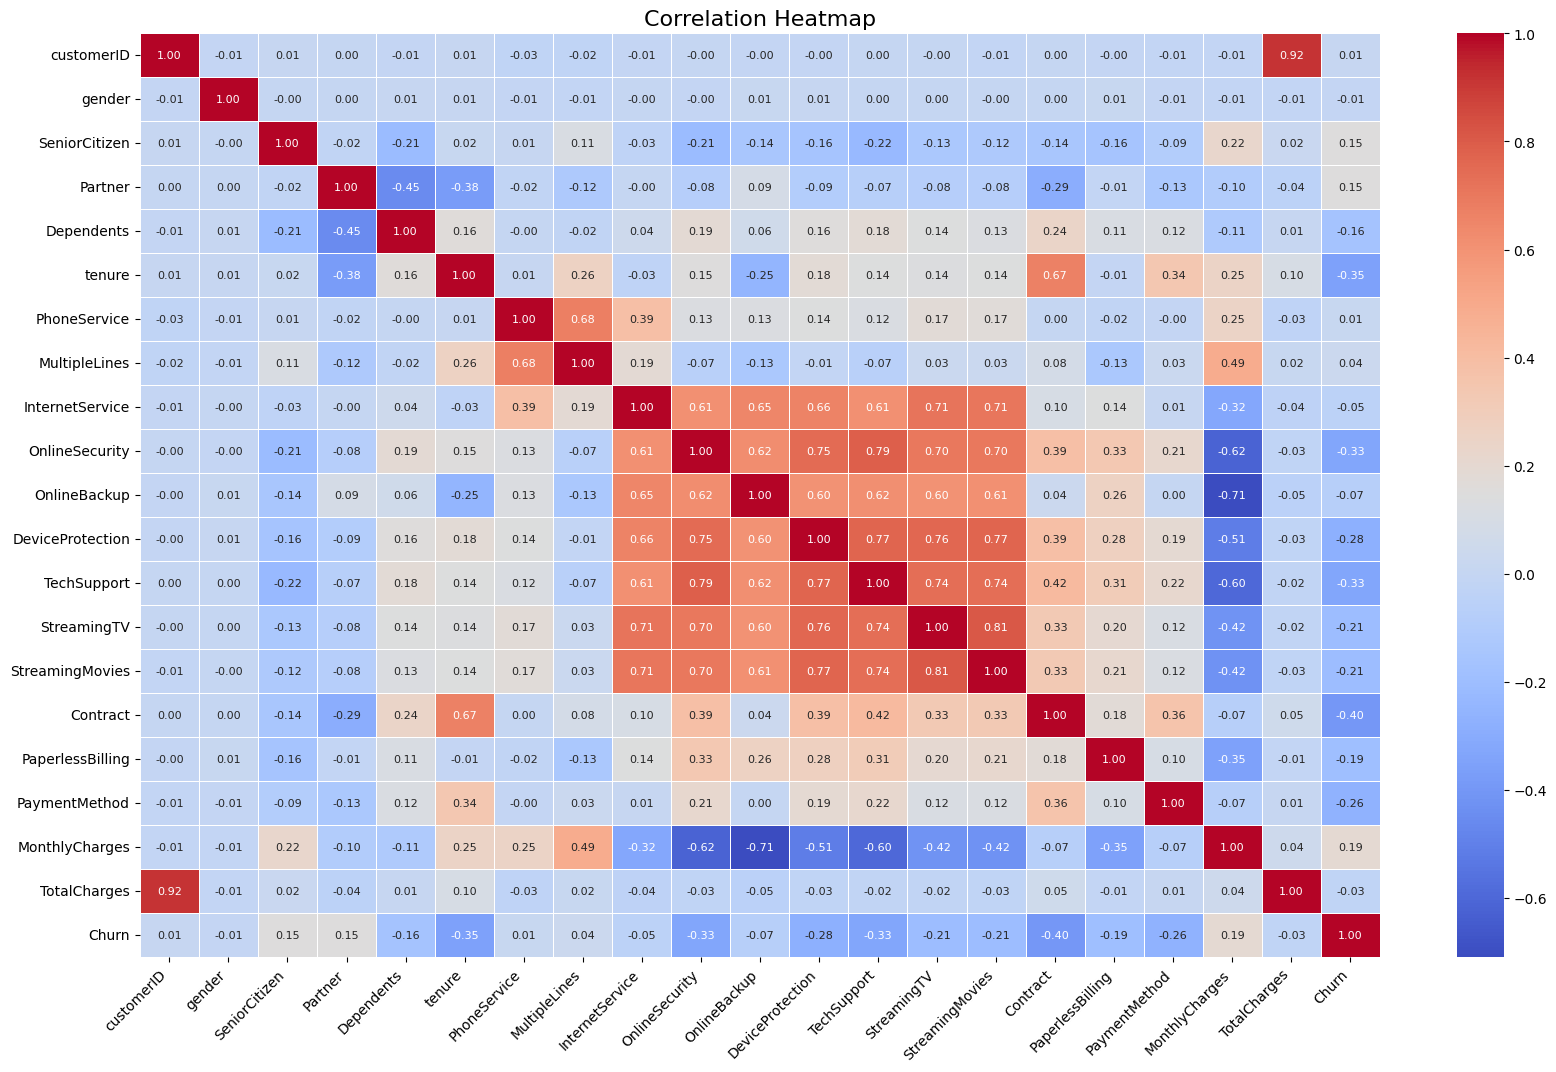

In [157]:
plt.figure(figsize=(20,12))

sns.heatmap(
    df_encoded.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    annot_kws={"size":8}
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.title('Correlation Heatmap', fontsize=16)

plt.show()

**MonthlyCharges** shows the strongest positive correlation with **Churn**, indicating that customers with higher monthly charges are more likely to discontinue service. Senior citizens also show slightly higher churn behavior.

# BUSINESS INSIGHT

1. Customers with **shorter tenure** periods are more likely to **churn.**

2. Customers with **month-to-month contracts** exhibit significantly **higher churn** rates.

3. **Higher monthly charges** are associated with increased **churn** behavior.

4. Customers with **Fiber optic internet** service have higher **churn.**

5. Customers with **electronic checks** have **high churn**.

# DATA PREPROCESSING

In [158]:
# Ubah fitur TotalCharges dari objek ke numerik
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [159]:
# Cek Missing Value setelah convert ke numerik
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [160]:
# Handle Missing Value dan Cek Hasil
df.dropna(inplace=True)
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [161]:
# Drop CustomerID
df.drop('customerID', axis=1, inplace=True)

**ENCODING**

In [162]:
# Encoding Fitur Target (Churn)
df['Churn'] = df['Churn'].map({
    'Yes':1,
    'No':0
})

In [163]:
# Encoding Kolom Binary (Yes/No) dengan mapping manual
binary_cols = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling'
]

for col in binary_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

In [164]:
# One Hot Encoding untuk fitur kategorikal
df = pd.get_dummies(
    df,
    columns=[
        'MultipleLines',
        'InternetService',
        'OnlineSecurity',
        'OnlineBackup',
        'DeviceProtection',
        'TechSupport',
        'StreamingTV',
        'StreamingMovies',
        'Contract',
        'PaymentMethod'
    ],
    drop_first=True
)

In [165]:
# Pisahkan Feature dan Target
X = df.drop('Churn', axis=1)
y = df['Churn']

In [166]:
# Splitting  Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [167]:
# Feature Scalling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [168]:
# SMOTE Untuk Handling Imbalance
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

# MODELLING

**Logistic Regression (Baseline Model)**

In [169]:
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

lr.fit(X_train_smote, y_train_smote)

y_pred_lr = lr.predict(X_test)

y_prob_lr = lr.predict_proba(X_test)[:,1]

In [170]:
# Classificaton Report Lr
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1033
           1       0.50      0.78      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.75      1407



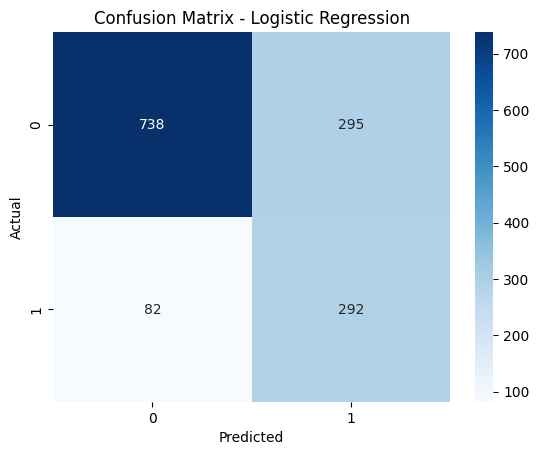

In [171]:
# Confussion Matrix Lr
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')

plt.show()

**XGBoost**

In [172]:
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=2,
    random_state=42
)

xgb.fit(X_train_smote, y_train_smote)

y_pred_xgb = xgb.predict(X_test)

y_prob_xgb = xgb.predict_proba(X_test)[:,1]

In [173]:
# Evaluasi XGBoost
print(classification_report(y_test,y_pred_xgb))

              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1033
           1       0.51      0.80      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.75      1407



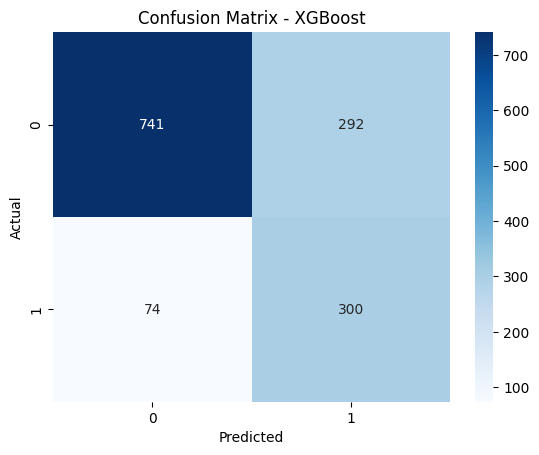

In [174]:
# Confussion Matrix XGB
cm = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost')

plt.show()

After applying **SMOTE** and **class balancing** techniques, the **XGBoost** model achieved the best performance with approximately **80%** recall and **83%** ROC-AUC, making it highly effective in identifying customers at risk of churn.

**Bandingkan Kedua Model**

In [175]:
comparison = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'XGBoost'
    ],

    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_xgb)
    ],

    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_xgb)
    ],

    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_xgb)
    ],

    'F1-Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_xgb)
    ],

    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.732054,0.497445,0.780749,0.607700,0.833889
1,XGBoost,0.739872,0.506757,0.802139,0.621118,0.831701


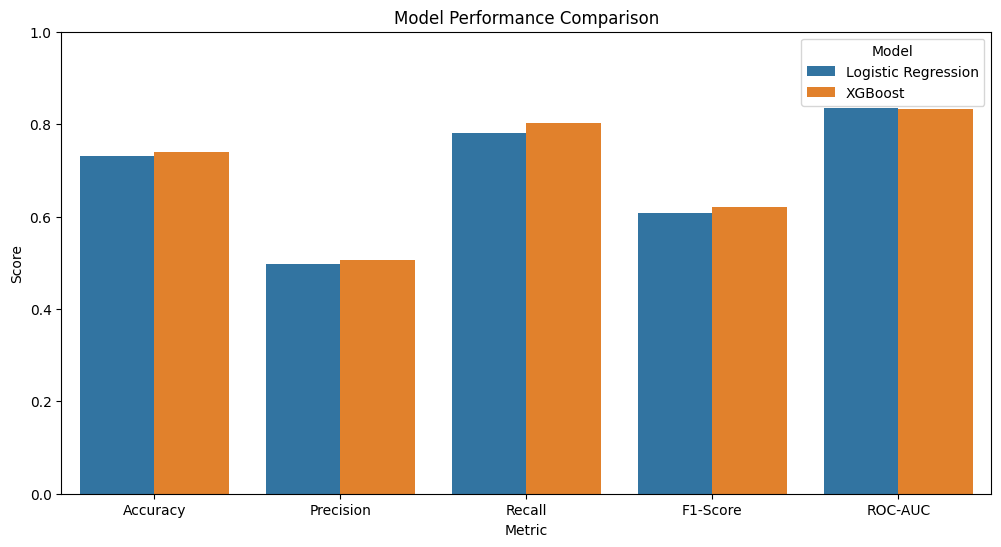

In [176]:
# Visualisasi Pebandingan Model
comparison_melted = comparison.melt(
    id_vars='Model',
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=comparison_melted,
    x='Metric',
    y='Score',
    hue='Model'
)

plt.title('Model Performance Comparison')

plt.ylim(0,1)

plt.show()

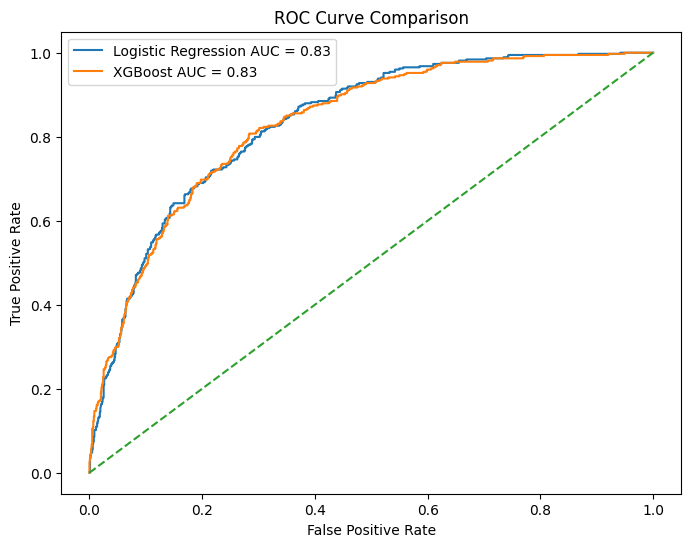

In [177]:
# ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    y_prob_lr
)

fpr_xgb, tpr_xgb, _ = roc_curve(
    y_test,
    y_prob_xgb
)

roc_auc_lr = auc(fpr_lr, tpr_lr)

roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f'Logistic Regression AUC = {roc_auc_lr:.2f}'
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f'XGBoost AUC = {roc_auc_xgb:.2f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.title('ROC Curve Comparison')

plt.legend()

plt.show()

# FEATURE IMPORTANCE

In [178]:
# Feature Importance - XGBoost
importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': xgb.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

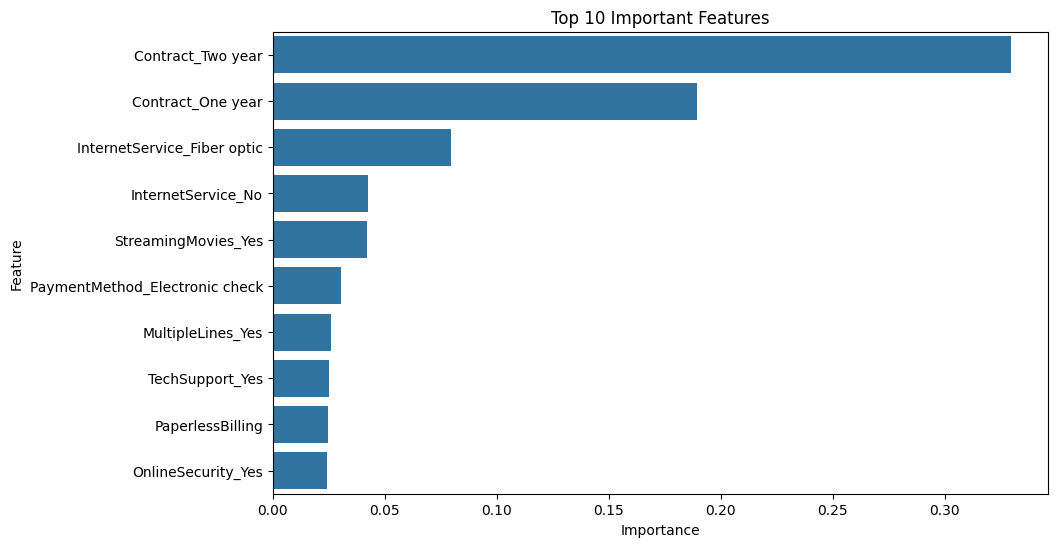

In [179]:
# Visualisasi Feature Importance - TOP 10 Feature
top_features = importance.head(10)
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features
)

plt.title(
    'Top 10 Important Features'
)

plt.show()

# CROSS VALIDATION


In [180]:
cv_scores = cross_val_score(
    xgb,
    X,
    y,
    cv=5,
    scoring='recall'
)

print('Cross Validation Recall:')

print(cv_scores)

print('Mean Recall:')

print(cv_scores.mean())

Cross Validation Recall:
[0.73529412 0.71657754 0.69705094 0.70588235 0.6631016 ]
Mean Recall:
0.7035813106622127


On average, the model is able to detect around **70%** of customer churn across various data shares.

# BUSINESS RECOMENDATION


1. Encourage customers to switch to long-term contracts through special promotions and benefits.
2. Improve onboarding and loyalty programs for new customers with short tenure.
3. Improving the quality of technical support to increase customer retention.
4. Provide promos or special offers to customers with high monthly charges.


# SAVE MODEL

In [181]:
import joblib

# Save model
joblib.dump(xgb, 'xgboost_churn_model.pkl')

# Save scaler
joblib.dump(scaler, 'scaler.pkl')

# Save columns
joblib.dump(X.columns.tolist(), 'model_columns.pkl')

print("Model saved successfully!")

Model saved successfully!
